In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams["text.usetex"] = False

In [2]:
#synthetic
vary_acc = pd.read_csv("final_data/vary_acc.csv")
#vary m files d = 16
vary_m_64 = pd.read_csv("final_data/vary_m_64.csv")
vary_m_128 = pd.read_csv("final_data/vary_m_128.csv")
vary_m_256 = pd.read_csv("final_data/vary_m_256.csv")
vary_m_512 = pd.read_csv("final_data/vary_m_512.csv")
vary_m_1024 = pd.read_csv("final_data/vary_m_1024.csv")
vary_m_2048 = pd.read_csv("final_data/vary_m_2048.csv")
vary_m_4096 = pd.read_csv("final_data/vary_m_4096.csv")
vary_m_8192 = pd.read_csv("final_data/vary_m_8192.csv")
vary_m_16384 = pd.read_csv("final_data/vary_m_16384.csv")
vary_m_32768 = pd.read_csv("final_data/vary_m_32768.csv")
# vary_m_131072 = pd.read_csv("vary_m/vary_m_131072.csv")

#vary m files d =8
vary_m_256_8 = pd.read_csv("final_data/vary_m_256_d_8.csv")
vary_m_512_8 = pd.read_csv("final_data/vary_m_512_d_8.csv")
vary_m_1024_8 = pd.read_csv("final_data/vary_m_1024_d_8.csv")
vary_m_2048_8 = pd.read_csv("final_data/vary_m_2048_d_8.csv")
vary_m_4096_8 = pd.read_csv("final_data/vary_m_4096_d_8.csv")
vary_m_8192_8 = pd.read_csv("final_data/vary_m_8192_d_8.csv")
vary_m_16384_8 = pd.read_csv("final_data/vary_m_16384_d_8.csv")
vary_m_32768_8 = pd.read_csv("final_data/vary_m_32768_d_8.csv")
vary_m_65536_8 = pd.read_csv("final_data/vary_m_65536_d_8.csv")

In [3]:
#real
pareto_label_1 = pd.read_csv("final_data/pareto_label_1.csv")
pareto_label_2 = pd.read_csv("final_data/pareto_label_2.csv")
pareto_v_as_feature = pd.read_csv("final_data/pareto_v_as_feature.csv")
tcm = pd.read_csv("final_data/final_summary_tcm.csv")

In [4]:
# rows to duplicate
mask = (
    (tcm["m"] == 10000) &
    (tcm["c"].isin([0.1, 1]))
)

# copy matching rows
dup = tcm[mask].copy()

# change c(m) values
dup.loc[dup["c"] == 0.1, "c(m)"] = "np.sqrt(m)/1000"
dup.loc[dup["c"] == 1, "c(m)"] = "np.sqrt(m)/100"

# append duplicated rows back to dataframe
tcm = pd.concat([tcm, dup], ignore_index=True)

In [5]:
tcm["pct_pay"] = 100 * tcm["number_of_payers"] / tcm["m"]
relevant_cm = ['np.sqrt(m)/1000']
losses = sorted(tcm["loss"].unique())
tcm = tcm[tcm["c(m)"].isin(relevant_cm)]
hinge_df = tcm[tcm["loss"] == "hinge"]
square_df = tcm[tcm["loss"] == "squared_hinge"]
log_df = tcm[tcm["loss"] == "log"]
markers = ['o', 's', '^']
labels = ['hinge loss', 'squared hinge', 'log loss']
ms = tcm["m"].unique()
hinge_grouped = (hinge_df.groupby(["m", "c(m)"], as_index=False).agg({"number_of_payers": "mean", "pct_pay": "mean"}).sort_values("m"))
square_grouped = (square_df.groupby(["m", "c(m)"], as_index=False).agg({"number_of_payers": "mean", "pct_pay": "mean"}).sort_values("m"))
log_grouped = (log_df.groupby(["m", "c(m)"], as_index=False).agg({"number_of_payers": "mean", "pct_pay": "mean"}).sort_values("m"))
# for loss_name in losses:


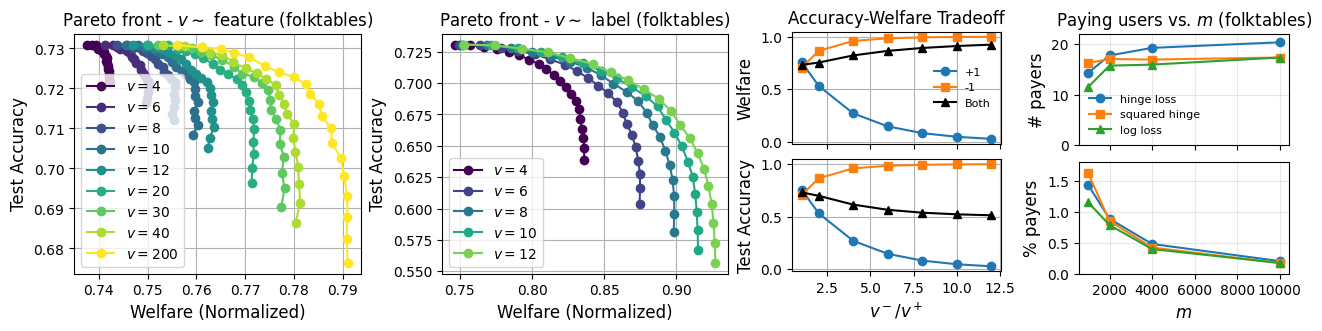

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.cm as cm

fig = plt.figure(figsize=(13, 3.2), constrained_layout=True)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.0, width_ratios=[1, 1, 1, 1])


vs = sorted(pareto_v_as_feature['v'].unique())
colors = cm.viridis(np.linspace(0, 1, len(vs)))

# =========================================================
# (1) Pareto: v as feature (full height col 0)
# =========================================================
ax1 = fig.add_subplot(gs[:, 0])

for i, v in enumerate(vs):
    subset = pareto_v_as_feature[pareto_v_as_feature['v'] == v]
    ax1.plot(
        subset['avg_welfare_test'],
        subset['avg_acc_test'],
        marker='o',
        color=colors[i],
        label=rf'$v={v}$'
    )

ax1.set_title(r'Pareto front - $v \sim$ feature (folktables)', fontsize=12)
ax1.set_xlabel(r'Welfare (Normalized)', fontsize=12)
ax1.set_ylabel(r'Test Accuracy', fontsize=12)
ax1.grid(True)
ax1.legend(fontsize=10)

# =========================================================
# (2) Pareto: v as label (full height col 1)
# =========================================================
vs = sorted(pareto_label_2['v'].unique())
colors = cm.viridis(np.linspace(0, 1, len(vs)))
ax2 = fig.add_subplot(gs[:, 1])
norm_welfare_train = pareto_label_2.copy()
norm_welfare_test = pareto_label_2.copy()
for i, v in enumerate(vs[1:]):
    subset = norm_welfare_test[norm_welfare_test['v'] == v].sort_values('alpha')
    ax2.plot(
        subset['test_welfare'],
        subset['test_acc'],
        marker='o',
        color=colors[i],
        label=rf'$v={v}$'
    )

ax2.set_title(r'Pareto front - $v \sim$ label (folktables)', fontsize=12)
ax2.set_xlabel(r'Welfare (Normalized)', fontsize=12)
ax2.set_ylabel(r'Test Accuracy', fontsize=12)
ax2.grid(True)
ax2.legend(fontsize=10)

# =========================================================
# (3) Plot 3: split vertically (col 2)
# =========================================================
gs3 = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[:, 2], hspace=0.05, height_ratios=[1, 1])

ax3_top = fig.add_subplot(gs3[0, 0])
ax3_bot = fig.add_subplot(gs3[1, 0], sharex=ax3_top)

ax3_top.tick_params(labelbottom=False)

vs3 = pareto_label_1["v_neg"]

ax3_top.plot(vs3, pareto_label_1["test_welfare_pos"], marker='o', label="+1")
ax3_top.plot(vs3, pareto_label_1["test_welfare_neg"], marker='s', label="-1")
ax3_top.plot(vs3, pareto_label_1["test_welfare"], color='black', marker='^', label="Both")

ax3_top.set_title(r'Accuracy-Welfare Tradeoff', fontsize=12)
ax3_top.set_ylabel(r'Welfare', fontsize=12)
ax3_top.grid(True)

ax3_bot.plot(vs3, pareto_label_1["test_acc_pos"], marker='o')
ax3_bot.plot(vs3, pareto_label_1["test_acc_neg"], marker='s')
ax3_bot.plot(vs3, pareto_label_1["test_acc"], color='black', marker='^')

ax3_bot.set_ylabel(r'Test Accuracy', fontsize=12)
ax3_bot.set_xlabel(r'$v^-/v^+$', fontsize=12)
ax3_bot.grid(True)

ax3_top.legend(frameon=False, fontsize=8)

# =========================================================
# (4) Plot 4: split vertically (col 3)
# =========================================================
gs4 = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[:, 3], hspace=0.05)

ax4_top = fig.add_subplot(gs4[0, 0])
ax4_bot = fig.add_subplot(gs4[1, 0], sharex=ax4_top)

ax4_top.tick_params(labelbottom=False)

ax4_top.set_ylim(bottom=0, top=22)
ax4_top.plot(ms, hinge_grouped["number_of_payers"], marker=markers[0], linestyle='-', label=labels[0])
ax4_top.plot(ms, square_grouped["number_of_payers"], marker=markers[1], linestyle='-', label=labels[1])
ax4_top.plot(ms, log_grouped["number_of_payers"], marker=markers[2], linestyle='-', label=labels[2])
ax4_top.set_ylabel(r"# payers", fontsize=12)
ax4_top.grid(True, alpha=0.3)

ax4_bot.set_ylim(bottom=0, top=1.8)
ax4_bot.plot(ms, hinge_grouped["pct_pay"], marker=markers[0], linestyle='-', label=labels[0])
ax4_bot.plot(ms, square_grouped["pct_pay"], marker=markers[1], linestyle='-', label=labels[1])
ax4_bot.plot(ms, log_grouped["pct_pay"], marker=markers[2], linestyle='-', label=labels[2])
ax4_bot.set_ylabel(r"% payers", fontsize=12)
ax4_bot.set_xlabel(r"$m$", fontsize=12)
ax4_bot.grid(True, alpha=0.3)

ax4_top.set_title(r"Paying users vs. $m$ (folktables)", fontsize=12)
ax4_top.set_ylabel(r'# payers', fontsize=12)
ax4_top.grid(True)

ax4_bot.set_ylabel(r"% payers", fontsize=12)
ax4_bot.set_xlabel(r"$m$", fontsize=12)
ax4_bot.grid(True)
ax4_top.legend(frameon=False, fontsize=8)

# =========================================================
# Save
# =========================================================
fig.savefig("figs/combined_panels.pdf", bbox_inches="tight")
fig.savefig("figs/combined_panels.png", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_1994592/96756489.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


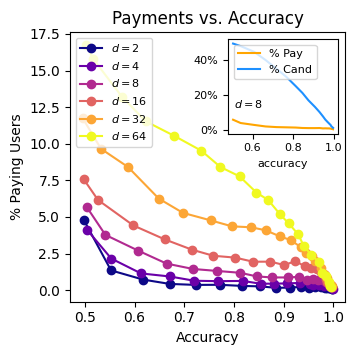

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import numpy as np
from matplotlib.ticker import PercentFormatter

def acc_num_payers_with_inset(mega_df, var, T, ds, labels=[1, -1]):

    # ---------- MAIN GRAPH ----------

    mean_accuracy_train = (
        mega_df
        .groupby(['d', var])['valid_acc']
        .mean()
        .unstack(level=0)
    )

    mean_num_payers = (
        mega_df[mega_df['label'].isin(labels)]
        .assign(pos=lambda df: df['critical_v'] > 0)
        .groupby([var, 'd', 't'])['pos']
        .mean()
        .mul(100)
        .groupby([var, 'd'])
        .mean()
        .unstack('d', fill_value=0)
    )

    fig, ax1 = plt.subplots(figsize=(3.65, 3.65))

    colors = cm.plasma(np.linspace(0, 1, mean_num_payers.shape[1]))

    for i, d in enumerate(mean_num_payers.columns):
        ax1.plot(
            mean_accuracy_train[d],
            mean_num_payers[d],
            'o-',
            color=colors[i],
            label=rf"$d={int(d)}$"
        )

    ax1.set_ylabel(r"% Paying Users")
    ax1.set_xlabel(r"Accuracy")
    ax1.set_title(r"Payments vs. Accuracy")

    ax1.legend(loc="upper left", frameon=True, fontsize=8)

    # μ = 0 annotation (main plot)
    # ax1.text(
    #     0.02, 0.1, r"$\mu=0$",
    #     transform=ax1.transAxes,
    #     fontsize=9,
    #     va='top'
    # )

    # ---------- INSET GRAPH ----------

    inset_ax = inset_axes(ax1, width="40%", height="35%", loc="upper right")

    df_filtered = mega_df[
        (mega_df['label'].isin(labels)) &
        (mega_df['d'].isin(ds))
    ]

    mean_accuracy_test_2 = (
        df_filtered
        .groupby(['d', var])['valid_acc']
        .mean()
        .unstack(level=0)
    )

    mean_num_payers_2 = (
        df_filtered
        .assign(pos=lambda df: df['critical_v'] > 0)
        .groupby([var, 'd', 't'])['pos']
        .mean()
        .mul(100)
        .groupby([var, 'd'])
        .mean()
        .unstack('d', fill_value=0)
    )

    mean_num_relevants_2 = (
        df_filtered
        .groupby([var, 'd', 't'])['is_relevant']
        .mean()
        .mul(100)
        .groupby([var, 'd'])
        .mean()
        .unstack('d', fill_value=0)
    )

    inset_colors = ['orange', 'dodgerblue']

    inset_ax.plot(
        mean_accuracy_test_2,
        mean_num_payers_2,
        '-',
        label="% Pay",
        color=inset_colors[0]
    )
    inset_ax.plot(
        mean_accuracy_test_2,
        mean_num_relevants_2,
        '-',
        label="% Cand",
        color=inset_colors[1]
    )

    inset_ax.legend(loc="upper left", fontsize=8)

    inset_ax.set_xlabel("accuracy", fontsize=8)

    # % formatting on y-axis
    inset_ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    inset_ax.tick_params(labelsize=8)

    # d = 8 annotation in inset
    inset_ax.text(
        0.05, 0.25, r"$d=8$",
        transform=inset_ax.transAxes,
        fontsize=8,
        va='bottom'
    )

    fig.tight_layout()

    fig.savefig("figs/payment_accuracy.pdf", bbox_inches="tight")
    fig.savefig("figs/payment_accuracy.png", dpi=300, bbox_inches="tight")
    fig.savefig("figs/payment_accuracy.jpg", dpi=300, bbox_inches="tight")
    fig.savefig("figs/payment_accuracy.eps", format="eps", bbox_inches="tight")

    plt.show()


acc_num_payers_with_inset(vary_acc, "mu", T = 50, ds = [8], labels=[1, -1])

6


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


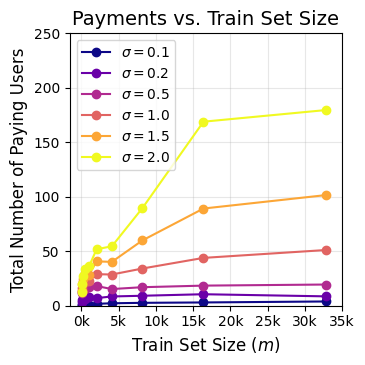

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm

def plot_mean_num_payers_m(mega_df, d, labels=[1, -1]):
    # Compute fraction of agents paying per trial
    # For each (sigma, m_total, t): # paying agents / total agents in that trial
    max_t = (max(mega_df['t'].unique())+1)
    mean_num_payers = ( (mega_df[(mega_df['critical_v'] > 0) & (mega_df['sigma'] < 2.5)
                                   & (mega_df['label'].isin(labels)) & (mega_df['d'] == d)])
                                   .groupby([ 'sigma', 'm_total'])['critical_v'].count()
                                   .unstack(level=0).fillna(0)) / max_t 

    # Create figure
    fig, ax1 = plt.subplots(figsize=(3.75,3.75))
    print(mean_num_payers.shape[1])
    # Colormap
    colors = cm.plasma(np.linspace(0,1,mean_num_payers.shape[1]))

    # Plot each line
    for idx, col in enumerate(mean_num_payers.columns):
        ax1.plot(
            mean_num_payers.index,
            mean_num_payers[col],
            'o-',
            color=colors[idx],
            label=rf"$\sigma = {col}$"
        )

    # LaTeX labels and title
    ax1.set_xlabel(r"Train Set Size ($m$)", fontsize=12)
    ax1.set_ylabel(r"Total Number of Paying Users", fontsize=12)
    ax1.set_title(r"Payments vs. Train Set Size", fontsize=14)
    ax1.set_ylim(0,250)
    ax1.legend()#frameon=False, fontsize=10)
    ax1.grid(True, alpha=0.3)

    x_max = mean_num_payers.index.max()
    xticks = np.arange(0, x_max + 5000, 5000)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f"{int(x/1000)}k" for x in xticks])

    fig.tight_layout()

    fig.savefig("figs/payment_m.pdf", bbox_inches="tight")
    fig.savefig("figs/payment_m.png", dpi=300, bbox_inches="tight")
    fig.savefig("figs/payment_m.jpg", dpi=300, bbox_inches="tight")
    fig.savefig("figs/payment_m.eps", format="eps", bbox_inches="tight")





dfs = [vary_m_64, vary_m_128, vary_m_256, vary_m_512, vary_m_1024, vary_m_2048, vary_m_4096, vary_m_8192, vary_m_16384, vary_m_32768]  # each has a different m_total
mega_df = pd.concat(dfs, ignore_index=True)

plot_mean_num_payers_m(mega_df, d = 16, labels = [1, -1])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


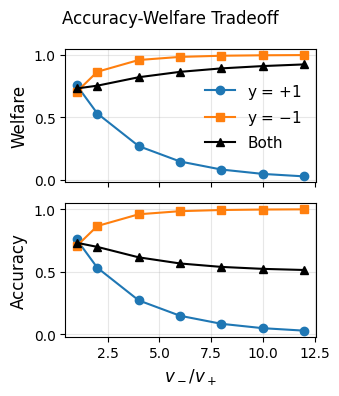

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Create figure with 2 rows, 1 column, shared x-axis
fig, axes = plt.subplots(2, 1, figsize=(3.5,4), sharex=True)

vs = pareto_label_1["v_neg"]  # x-axis

# Neutral colors (grayscale)

markers = ['o', 's', '^']
labels = [r'y = $+1$', r'y = $-1$', r'Both']

# ------------------------
# Subplot 1: Test Welfare
# ------------------------
ax = axes[0]
ax.plot(vs, pareto_label_1["test_welfare_pos"], marker=markers[0], linestyle='-', label=labels[0])
ax.plot(vs, pareto_label_1["test_welfare_neg"], marker=markers[1],  linestyle='-', label=labels[1])
ax.plot(vs, pareto_label_1["test_welfare"], marker=markers[2], color='black', linestyle='-', label=labels[2])
ax.set_ylabel(r"Welfare", fontsize=12)
ax.grid(True, alpha=0.3)

# ------------------------
# Subplot 2: Test Accuracy
# ------------------------
ax = axes[1]
ax.plot(vs, pareto_label_1["test_acc_pos"], marker=markers[0], linestyle='-', label=labels[0])
ax.plot(vs, pareto_label_1["test_acc_neg"], marker=markers[1], linestyle='-', label=labels[1])
ax.plot(vs, pareto_label_1["test_acc"], marker=markers[2], color='black', linestyle='-', label=labels[2])
ax.set_ylabel(r"Accuracy", fontsize=12)
ax.set_xlabel(r"$v_- / v_+$", fontsize=12)
ax.grid(True, alpha=0.3)

# ------------------------
# Shared legend at the bottom
# ------------------------
axes[0].legend(labels, loc='center right', fontsize=11, frameon=False, title=None)


# Overall title in LaTeX
fig.suptitle(r"Accuracy-Welfare Tradeoff")

plt.tight_layout()

fig.tight_layout()

fig.savefig("figs/acc_welfare_tradeoff.pdf", bbox_inches="tight")
fig.savefig("figs/acc_welfare_tradeoff.png", dpi=300, bbox_inches="tight")
fig.savefig("figs/acc_welfare_tradeoff.jpg", dpi=300, bbox_inches="tight")
fig.savefig("figs/acc_welfare_tradeoff.eps", format="eps", bbox_inches="tight")



plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


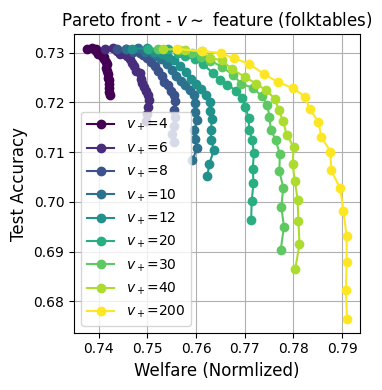

In [10]:
#remove train 
# ---- Sort alphas
alphas_sorted = sorted(pareto_v_as_feature['alpha'].unique())
vs = sorted(pareto_v_as_feature['v'].unique())

# ---- Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 1, figsize=(3.8, 4))

# Colormap
colors = cm.viridis(np.linspace(0,1,len(vs)))

# ---- Right subplot: Test Accuracy vs Normalized Test Welfare
for i, v in enumerate(vs):
    subset = pareto_v_as_feature[pareto_v_as_feature['v'] == v]
    # Normalize test welfare per v
    norm_welfare_test = subset['avg_welfare_test'] 
    axes.plot(
        norm_welfare_test,
        subset['avg_acc_test'],
        marker='o',
        linestyle='-',
        color = colors[i],
        label=rf'$v_+$={v}'
    )

axes.set_xlabel(r'Welfare (Normlized)', fontsize=12)
axes.set_ylabel(r'Test Accuracy', fontsize=12)
axes.set_title(r'Pareto front - $v \sim$ feature (folktables)', fontsize=12)
axes.legend()
axes.grid(True)

fig.tight_layout()

fig.savefig("figs/pareto_feature.pdf", bbox_inches="tight")
fig.savefig("figs/pareto_feature.png", dpi=300, bbox_inches="tight")
fig.savefig("figs/pareto_feature.jpg", dpi=300, bbox_inches="tight")
fig.savefig("figs/pareto_feature.eps", format="eps", bbox_inches="tight")


plt.tight_layout()
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


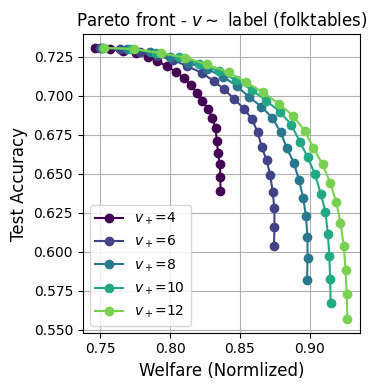

In [11]:
# Get sorted unique values
alphas_sorted = sorted(pareto_label_2['alpha'].unique())
vs = sorted(pareto_label_2['v'].unique())

# ---- PER-v MAX NORMALIZATION (column-wise)
norm_welfare_train = pareto_label_2.copy()
norm_welfare_test = pareto_label_2.copy()

for v in vs:
    norm_welfare_train.loc[norm_welfare_train['v'] == v, 'train_welfare'] 
    norm_welfare_test.loc[norm_welfare_test['v'] == v, 'test_welfare'] 

# ---- Create subplots
fig, axes = plt.subplots(1, 1, figsize=(3.8, 4))

colors = cm.viridis(np.linspace(0,1,len(vs)))
# ---- Right: Test Accuracy vs Normalized Test Welfare
for i, v in enumerate(vs[1:]):
    subset = norm_welfare_test[norm_welfare_test['v'] == v].sort_values('alpha')
    axes.plot(
        subset['test_welfare'],
        subset['test_acc'],
        marker='o',
        linestyle='-',
        color = colors[i],
        label=rf'$v_+$={v}'
    )
axes.set_xlabel(r'Welfare (Normlized)', fontsize=12)
axes.set_ylabel(r'Test Accuracy', fontsize=12)
axes.set_title(r'Pareto front - $v \sim$ label (folktables)', fontsize=12)
axes.legend()
axes.grid(True)

fig.tight_layout()

fig.savefig("figs/pareto_label_1.pdf", bbox_inches="tight")
fig.savefig("figs/pareto_label_1.png", dpi=300, bbox_inches="tight")
fig.savefig("figs/pareto_label_1.jpg", dpi=300, bbox_inches="tight")
fig.savefig("figs/pareto_label_1.eps", format="eps", bbox_inches="tight")



plt.tight_layout()
plt.show()
